In [1]:
import os
cwd = os.getcwd()
print("Current Working Directory:", cwd)

Current Working Directory: /projectnb/cs598/students/achetia


/projectnb/cs598/students/achetia/venvs/Anup_Janus_env/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Question: How many Windows are visible in the scene?
1: 1
2: 0
3: 4
4: 2
5: 3
Correct Answer: 1


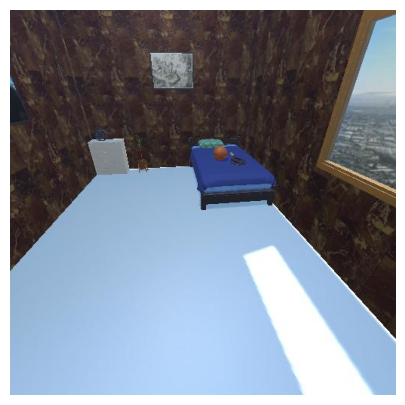

In [3]:
from datasets import load_dataset
import io
import matplotlib.pyplot as plt
import PIL
from PIL import Image

dataset = load_dataset("array/SAT", batch_size=128, cache_dir="/projectnb/cs598/students/achetia")
# dataset should have a training and validation key

example = dataset['train'][15] # example 10th item

images = [im_bytes for im_bytes in example['image_bytes']] # this is a list of images. Some questions are on one image, and some on 2 images
question = example['question']
answer_choices = example['answers']
correct_answer = example['correct_answer']

print(f"Question: {question}")
for idx, choice in enumerate(answer_choices):
    print(f"{idx + 1}: {choice}")

print(f"Correct Answer: {correct_answer}")

fig, axes = plt.subplots(1, len(images), figsize=(10, 5))

if len(images) == 1:
    axes.imshow(images[0])
    axes.axis("off")
else:
    for ax, img in zip(axes, images):
        ax.imshow(img)
        ax.axis("off")

plt.show()



In [4]:
%pip install nvidia-pyindex

  Preparing metadata (setup.py) ... done
  Created wheel for nvidia-pyindex: filename=nvidia_pyindex-1.0.9-py3-none-any.whl size=8418 sha256=d02eb93497912cc18d5eb0e781b85c404c14a628db3d1d0c95f8cae8ea49450d
  Stored in directory: /scratch/3147605.1.csgpu/pip-ephem-wheel-cache-e7tdtt2l/wheels/2c/af/d0/7a12f82cab69f65d51107f48bcd6179e29b9a69a90546332b3
Successfully built nvidia-pyindex

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install nvidia-nccl

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 94.4 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!nvidia-smi

Mon Mar 17 13:53:06 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.124.06             Driver Version: 570.124.06     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:17:00.0 Off |                    0 |
|  0%   68C    P0            293W /  300W |   34485MiB /  46068MiB |    100%   E. Process |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import transformers
from transformers import AutoModelForCausalLM, get_scheduler
from janus.models import VLChatProcessor
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from datasets import load_dataset
import os
import PIL
from PIL import Image
import io
import numpy as np
from accelerate import Accelerator
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

/projectnb/cs598/students/achetia/venvs/AJ/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python version is above 3.10, patching the collections module.


/projectnb/cs598/students/achetia/venvs/AJ/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/projectnb/cs598/students/achetia/venvs/AJ/lib/python3.10/site-packages/torchvision/transforms/v2/__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback

In [3]:
model_path = "deepseek-ai/Janus-Pro-7B"
cache_dir = "/projectnb/cs598/students/achetia/model"
output_dir = "./janus-pro-lora-finetuned"
dataset_name = "array/SAT"

In [4]:
num_epochs = 3
learning_rate = 2e-4
weight_decay = 0.01
batch_size = 1
num_accumulation_steps = 4
num_warmup_steps = 100
lr_scheduler_choice = "linear"
load_checkpoint = None

In [5]:
accelerator = Accelerator(gradient_accumulation_steps=num_accumulation_steps)
device = accelerator.device

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [6]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [7]:
print("Loading model and processor...")
vl_chat_processor = VLChatProcessor.from_pretrained(model_path, cache_dir=cache_dir)
tokenizer = vl_chat_processor.tokenizer

vl_gpt = AutoModelForCausalLM.from_pretrained(
    model_path, 
    trust_remote_code=True, 
    cache_dir=cache_dir
)
vl_gpt = vl_gpt.to(torch.float16)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading model and processor...


You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message.
Some kwargs in processor config are unused and will not have any effect: mask_prompt, num_image_tokens, add_special_token, sft_format, ignore_id, image_tag. 
Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]/projectnb/cs598/students/achetia/venvs/AJ/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. 

In [8]:
import GPUtil

# Get all GPUs
gpus = GPUtil.getGPUs()

# Print details for each GPU
for gpu in gpus:
    print(f"GPU ID: {gpu.id}")
    print(f"GPU Name: {gpu.name}")
    print(f"Total Memory: {gpu.memoryTotal} MB")
    print(f"Free Memory: {gpu.memoryFree} MB")
    print(f"Memory Utilization: {gpu.memoryUtil*100:.2f}%")
    print(f"GPU Load: {gpu.load*100:.2f}%")
    print("-" * 30)


GPU ID: 0
GPU Name: NVIDIA A40
Total Memory: 46068.0 MB
Free Memory: 17641.0 MB
Memory Utilization: 60.47%
GPU Load: 51.00%
------------------------------
GPU ID: 1
GPU Name: NVIDIA A40
Total Memory: 46068.0 MB
Free Memory: 21871.0 MB
Memory Utilization: 51.29%
GPU Load: 36.00%
------------------------------
GPU ID: 2
GPU Name: NVIDIA A40
Total Memory: 46068.0 MB
Free Memory: 45496.0 MB
Memory Utilization: 0.01%
GPU Load: 0.00%
------------------------------
GPU ID: 3
GPU Name: NVIDIA A40
Total Memory: 46068.0 MB
Free Memory: 43593.0 MB
Memory Utilization: 4.14%
GPU Load: 26.00%
------------------------------


In [9]:
print("Preparing model for LoRA fine-tuning...")
model = prepare_model_for_kbit_training(vl_gpt)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Preparing model for LoRA fine-tuning...
trainable params: 37,478,400 || all params: 7,457,846,923 || trainable%: 0.5025


In [10]:
# @dataclass
# class SATDataCollator:
#     vl_chat_processor: VLChatProcessor
#     max_length: int = 512
    
#     def __call__(self, examples):
#         batch_inputs = []
#         batch_labels = []
#         batch_attention_masks = []
        
#         for example in examples:
#             images = [im_bytes for im_bytes in example["image_bytes"]]
            
#             question = example["question"]
#             answer_choices = example["answers"]
#             correct_answer = example["correct_answer"]
            
#             prompt = f"""
#             Instructions: Answer the following question using the given options.
#             Enclose your answer in [].
            
#             Question: {question}
            
#             Options: {answer_choices}
#             """
            
#             response = f"[{correct_answer}]"
            
#             conversation = [
#                 {
#                     "role": "<|User|>",
#                     "content": f"<image_placeholder>\n{prompt}",
#                     "images": images,
#                 },
#                 {"role": "<|Assistant|>", "content": response},
#             ]
            
#             inputs = self.vl_chat_processor(
#                 conversations=conversation, 
#                 images=images, 
#                 return_tensors="pt", 
#                 padding="max_length",
#                 max_length=self.max_length,
#                 truncation=True
#             )
            
#             input_ids = inputs.input_ids[0]
#             attention_mask = inputs.attention_mask[0]
            
#             assistant_token_id = tokenizer.encode("<|Assistant|>")[0]
#             assistant_pos = (input_ids == assistant_token_id).nonzero(as_tuple=True)[0][0]
            
#             # Create labels: -100 for non-target tokens
#             labels = input_ids.clone()
#             labels[:assistant_pos] = -100
            
#             batch_inputs.append(input_ids)
#             batch_labels.append(labels)
#             batch_attention_masks.append(attention_mask)
        
#         max_len = max(len(ids) for ids in batch_inputs)
        
#         padded_inputs = torch.ones((len(batch_inputs), max_len), dtype=torch.long) * tokenizer.pad_token_id
#         padded_labels = torch.ones((len(batch_labels), max_len), dtype=torch.long) * -100
#         attention_masks = torch.zeros((len(batch_inputs), max_len), dtype=torch.long)
        
#         for i, (input_ids, label_ids, attn_mask) in enumerate(zip(batch_inputs, batch_labels, batch_attention_masks)):
#             input_len = len(input_ids)
#             padded_inputs[i, :input_len] = input_ids
#             padded_labels[i, :input_len] = label_ids
#             attention_masks[i, :input_len] = attn_mask[:input_len]
        
#         return {
#             "input_ids": padded_inputs,
#             "attention_mask": attention_masks,
#             "labels": padded_labels
#         }

# print("Loading dataset")
# dataset = load_dataset(dataset_name, batch_size=128, cache_dir="/projectnb/cs598/students/achetia")

Loading dataset


In [13]:
# def preprocess_function(examples):
    
#     return {
#         "input_ids": examples["input_ids"],
#         "attention_mask": examples["attention_mask"],
#         "labels": examples["labels"] if "labels" in examples else None
#     }

# processed_dataset = dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/172384 [00:00<?, ? examples/s]


KeyError: 'input_ids'

In [10]:
print("Loading dataset")
dataset = load_dataset(dataset_name, batch_size=128, cache_dir="/projectnb/cs598/students/achetia")

Loading dataset


In [11]:
def process_example(example):
    images = [im_bytes for im_bytes in example["image_bytes"]]
    
    question = example["question"]
    answer_choices = example["answers"]
    correct_answer = example["correct_answer"]
    
    prompt = f"""
    Instructions: Answer the following question using the given options.
    Enclose your answer in [].
    
    Question: {question}
    
    Options: {answer_choices}
    """
    
    response = f"[{correct_answer}]"
    
    conversation = [
        {
            "role": "<|User|>",
            "content": f"<image_placeholder>\n{prompt}",
            "images": images,
        },
        {"role": "<|Assistant|>", "content": response},
    ]
    
    inputs = vl_chat_processor(
        conversations=conversation, 
        images=images, 
        return_tensors="pt", 
        padding="max_length",
        max_length=512,
        truncation=True
    )
    
    input_ids = inputs.input_ids[0]
    attention_mask = inputs.attention_mask[0]
    
    assistant_token_id = tokenizer.encode("<|Assistant|>")[0]
    assistant_pos = (input_ids == assistant_token_id).nonzero(as_tuple=True)[0][0]
    
    labels = input_ids.clone()
    labels[:assistant_pos] = -100
    
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }


In [12]:
def collate_fn(examples):
    max_len = max(len(example["input_ids"]) for example in examples)
    
    batch_size = len(examples)
    input_ids = torch.ones((batch_size, max_len), dtype=torch.long) * tokenizer.pad_token_id
    attention_mask = torch.zeros((batch_size, max_len), dtype=torch.long)
    labels = torch.ones((batch_size, max_len), dtype=torch.long) * -100
    
    for i, example in enumerate(examples):
        input_len = len(example["input_ids"])
        input_ids[i, :input_len] = example["input_ids"]
        attention_mask[i, :input_len] = example["attention_mask"][:input_len]
        labels[i, :input_len] = example["labels"][:input_len]
    
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }

In [ ]:
train_dataset = dataset["train"].map(process_example, remove_columns=dataset["train"].column_names)
eval_dataset = None
if "validation" in dataset:
    eval_dataset = dataset["validation"].map(process_example, remove_columns=dataset["validation"].column_names)

Map:   7%|▋         | 11590/172384 [37:54<8:40:58,  5.14 examples/s]IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)

Map:  18%|█▊        | 31641/172384 [1:41:30<7:15:22,  5.39 examples/s] 

In [ ]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=True
)

eval_dataloader = None
if eval_dataset:
    eval_dataloader = DataLoader(
        eval_dataset,
        batch_size=batch_size,
        collate_fn=collate_fn
    )


In [ ]:
optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = get_scheduler(
    lr_scheduler_choice,
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [ ]:
accelerator.register_for_checkpointing(lr_scheduler)
if load_checkpoint:
    accelerator.load_state(load_checkpoint)
    


In [ ]:
train_dataloader, model, optimizer = accelerator.prepare(
    train_dataloader, model, optimizer
)

if eval_dataloader:
    eval_dataloader = accelerator.prepare(eval_dataloader)

In [ ]:
model.train()
completed_steps = 0
progress_bar = tqdm(range(num_training_steps), disable=not accelerator.is_local_main_process)

In [ ]:
for epoch in range(num_epochs):
    for step, batch in enumerate(train_dataloader):
        with accelerator.accumulate(model):
            # Forward pass
            outputs = model(**batch)
            loss = outputs.loss
            
            # Backward pass
            accelerator.backward(loss)
            
            # Update weights
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
        
        # Update progress bar
        progress_bar.update(1)
        completed_steps += 1
        
        # Log progress
        if completed_steps % 10 == 0 and accelerator.is_local_main_process:
            progress_bar.set_description(f"Epoch: {epoch}, Loss: {loss.item():.4f}")
        
        # Save checkpoint
        if completed_steps % 200 == 0:
            accelerator.wait_for_everyone()
            unwrapped_model = accelerator.unwrap_model(model)
            save_path = f"{output_dir}/checkpoint-{completed_steps}"
            os.makedirs(save_path, exist_ok=True)
            unwrapped_model.save_pretrained(
                save_path,
                is_main_process=accelerator.is_main_process,
                save_function=accelerator.save
            )
            if accelerator.is_local_main_process:
                tokenizer.save_pretrained(save_path)
                accelerator.save_state(os.path.join(save_path, "accelerator_state"))


In [ ]:
accelerator.wait_for_everyone()
unwrapped_model = accelerator.unwrap_model(model)
unwrapped_model.save_pretrained(
    output_dir,
    is_main_process=accelerator.is_main_process,
    save_function=accelerator.save
)
if accelerator.is_local_main_process:
    tokenizer.save_pretrained(output_dir)
    accelerator.save_state(os.path.join(output_dir, "final_accelerator_state"))

print("Training completed!")

In [11]:
# data_collator = SATDataCollator(vl_chat_processor=vl_chat_processor, max_length=512)

In [12]:
# training_args = TrainingArguments(
#     output_dir=output_dir,
#     num_train_epochs=3,
#     per_device_train_batch_size=1,
#     gradient_accumulation_steps=4,
#     learning_rate=2e-4,
#     warmup_steps=100,
#     logging_steps=10,
#     save_steps=200,
#     fp16=True,  # Use mixed precision training
#     optim="adamw_torch",
#     report_to="tensorboard",
#     remove_unused_columns=False,
#     local_rank=-1,  # for distributed training
#     ddp_find_unused_parameters=False,
# )

In [13]:
# trainer = transformers.Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=dataset["train"],
#     eval_dataset=dataset["validation"] if "validation" in dataset else None,
#     data_collator=data_collator,
# )

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [14]:
# print("Starting training...")
# trainer.train()

Starting training...


TypeError: _forward_unimplemented() got an unexpected keyword argument 'input_ids'

In [ ]:
model.save_pretrained(output_dir)
vl_chat_processor.save_pretrained(output_dir)
print(f"Model saved to {output_dir}")

In [4]:
from janus_wraper import *

In [5]:
from tqdm import tqdm
import re
from PIL import Image
import io

# Function to extract the answer from the prediction text
def extract_ans(pred_text):
    matches = re.findall(r"\[(.*?)\]", pred_text)
    return matches

# Modified prediction function for the 'array/SAT' dataset
def evaluate_on_validation(dataset, vl_chat_processor, vl_gpt, device='cuda'):
    predictions = []
    n_correct = 0
    total = len(dataset['validation'])
    
    for i in (pbar := tqdm(range(total))):  
        example = dataset['validation'][i]  

        image_bytes = example['image_bytes']
        images = image_bytes  # List of images

        question = example['question']
        answer_choices = example['answers']
        correct_answer = example['correct_answer']

        input_prompt = f'''
                        Instructions: You have to answer the following question using the given options.
                                      Enclose your answer in []. 
                                      For example, if the answer is yes, it must be formatted like [yes].

                        Question: {question}

                        Image(s): {len(images)} image(s) are provided. 
                        Your answer must contain just the options given below. Enclose the answer in brackets like [answer]. 
                        Options: {answer_choices}
                '''

        # Generate the prediction text using the model
        prediction_text = janus_pro_generate(
            vl_chat_processor=vl_chat_processor,
            vl_gpt=vl_gpt,
            input_text=input_prompt,
            input_image=images,
            device=device,
            output_mode="text",
            temperature=0.1,
            top_p=0.95,
            seed=42
        )
        
        # Extract the prediction answer
        prediction = extract_ans(prediction_text)

        predictions.append({
            "question": question,
            "answers": answer_choices,
            "pred_text": prediction_text,
            "prediction": prediction,
            "correct_answer": correct_answer
        })

        # Check if the prediction matches the correct answer
        try:
            if len(prediction) == 1:
                if prediction[0].strip().lower() == correct_answer.strip().lower():
                    n_correct += 1
        except:
            pass

        # Update the progress bar description with accuracy
        accuracy = (n_correct / (i + 1)) * 100
        pbar.set_description(f'Accuracy: {accuracy:.2f}% ({n_correct}/{i+1})')

    # Calculate final accuracy
    final_accuracy = (n_correct / total) * 100
    print(f"Final accuracy: {final_accuracy:.2f}% ({n_correct}/{total})")
    
    return predictions, final_accuracy

# Run evaluation on validation set
validation_predictions, validation_accuracy = evaluate_on_validation(dataset, vl_chat_processor, vl_gpt)

# Save results to file
import json
with open('validation_results.json', 'w') as f:
    json.dump({
        'predictions': validation_predictions,
        'accuracy': validation_accuracy
    }, f, indent=2)

print(f"Results saved to validation_results.json")


280 correct:   0%|          | 570/172384 [05:24<27:11:32,  1.76it/s]


KeyboardInterrupt: 